*CUADERNO JUPYTER ECOMMERCE BRASIL OLIST*

Este es el cuaderno con todos los análisis y consultas realizadas con Python. Gracias a ellas podemos responder a las preguntas para conocer y visualizar los datos que sean necesarios.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%pip install psycopg2-binary

Note: you may need to restart the kernel to use updated packages.


In [2]:
from sqlalchemy import create_engine

# Datos de conexión base PostgreSQL
usuario = "postgres"
contrasena = "admin"   
host = "localhost"
puerto = "5432"
base = "olist"

# Crear motor de conexión
engine = create_engine(f"postgresql+psycopg2://{usuario}:{contrasena}@{host}:{puerto}/{base}")

# Probar que conecta
import pandas as pd
prueba = pd.read_sql("SELECT COUNT(*) AS total FROM orders", engine)
print(prueba)

   total
0  99441


In [3]:
consulta_cohortes = """
WITH primera_compra AS (
    SELECT 
        c.customer_unique_id,
        MIN(o.order_purchase_timestamp) AS fecha_primera
    FROM customers AS c
    JOIN orders AS o ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),
pedidos_cohorte AS (
    SELECT 
        pc.customer_unique_id,
        DATE_TRUNC('month', pc.fecha_primera) AS cohorte,
        (EXTRACT(YEAR FROM o.order_purchase_timestamp) - EXTRACT(YEAR FROM pc.fecha_primera)) * 12
        + (EXTRACT(MONTH FROM o.order_purchase_timestamp) - EXTRACT(MONTH FROM pc.fecha_primera)) AS mes_numero
    FROM primera_compra AS pc
    JOIN customers AS c ON pc.customer_unique_id = c.customer_unique_id
    JOIN orders AS o ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
)
SELECT 
    cohorte,
    mes_numero,
    COUNT(DISTINCT customer_unique_id) AS clientes_activos
FROM pedidos_cohorte
GROUP BY cohorte, mes_numero
ORDER BY cohorte, mes_numero;
"""

df_cohortes = pd.read_sql(consulta_cohortes, engine) #ejecuta la consulta y mete las 219 filas en un DataFrame llamado df_cohortes
print(df_cohortes.shape) #tamaño
df_cohortes.head()#primeras 5 lineas

(219, 3)


,cohorte,mes_numero,clientes_activos
0,2016-09-01,0.0,1
1,2016-10-01,0.0,262
2,2016-10-01,6.0,1
3,2016-10-01,9.0,1
4,2016-10-01,11.0,1


In [4]:
matriz = df_cohortes.pivot(index='cohorte', columns='mes_numero', values='clientes_activos')
matriz = matriz.fillna(0)
matriz_pct = matriz.divide(matriz[0], axis=0) * 100
cohortes_grandes = matriz[matriz[0] >= 50].index
matriz_pct = matriz_pct.loc[cohortes_grandes]
matriz_pct

mes_numero,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0
cohorte,,,,,,,,,,,,,,,,,,,,
2016-10-01,100.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.381679,0.000000,0.000000,0.381679,0.000000,0.381679,0.000000,0.381679,0.000000,0.381679,0.000000,0.381679,0.763359,0.763359
2017-01-01,100.0,0.278940,0.278940,0.139470,0.418410,0.139470,0.418410,0.139470,0.139470,0.000000,0.418410,0.139470,0.697350,0.418410,0.139470,0.139470,0.278940,0.418410,0.139470,0.000000
2017-02-01,100.0,0.184275,0.307125,0.122850,0.429975,0.122850,0.245700,0.184275,0.122850,0.184275,0.122850,0.307125,0.122850,0.184275,0.122850,0.061425,0.061425,0.184275,0.000000,0.000000
2017-03-01,100.0,0.439473,0.359569,0.399521,0.359569,0.159808,0.159808,0.319616,0.319616,0.079904,0.359569,0.119856,0.199760,0.119856,0.159808,0.239712,0.079904,0.119856,0.000000,0.000000
2017-04-01,100.0,0.620567,0.221631,0.177305,0.265957,0.265957,0.354610,0.310284,0.310284,0.177305,0.265957,0.088652,0.044326,0.044326,0.088652,0.088652,0.132979,0.000000,0.000000,0.000000
2017-05-01,100.0,0.463634,0.463634,0.289771,0.289771,0.318748,0.405680,0.144886,0.260794,0.260794,0.260794,0.347725,0.231817,0.028977,0.173863,0.202840,0.000000,0.000000,0.000000,0.000000
2017-06-01,100.0,0.493908,0.395127,0.428054,0.296345,0.395127,0.362200,0.230491,0.131709,0.197563,0.296345,0.362200,0.164636,0.164636,0.230491,0.000000,0.000000,0.000000,0.000000,0.000000
2017-07-01,100.0,0.533049,0.346482,0.239872,0.293177,0.213220,0.319829,0.106610,0.186567,0.266525,0.213220,0.293177,0.133262,0.239872,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2017-08-01,100.0,0.690165,0.345083,0.271136,0.345083,0.517624,0.295785,0.271136,0.147893,0.147893,0.246488,0.197190,0.123244,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


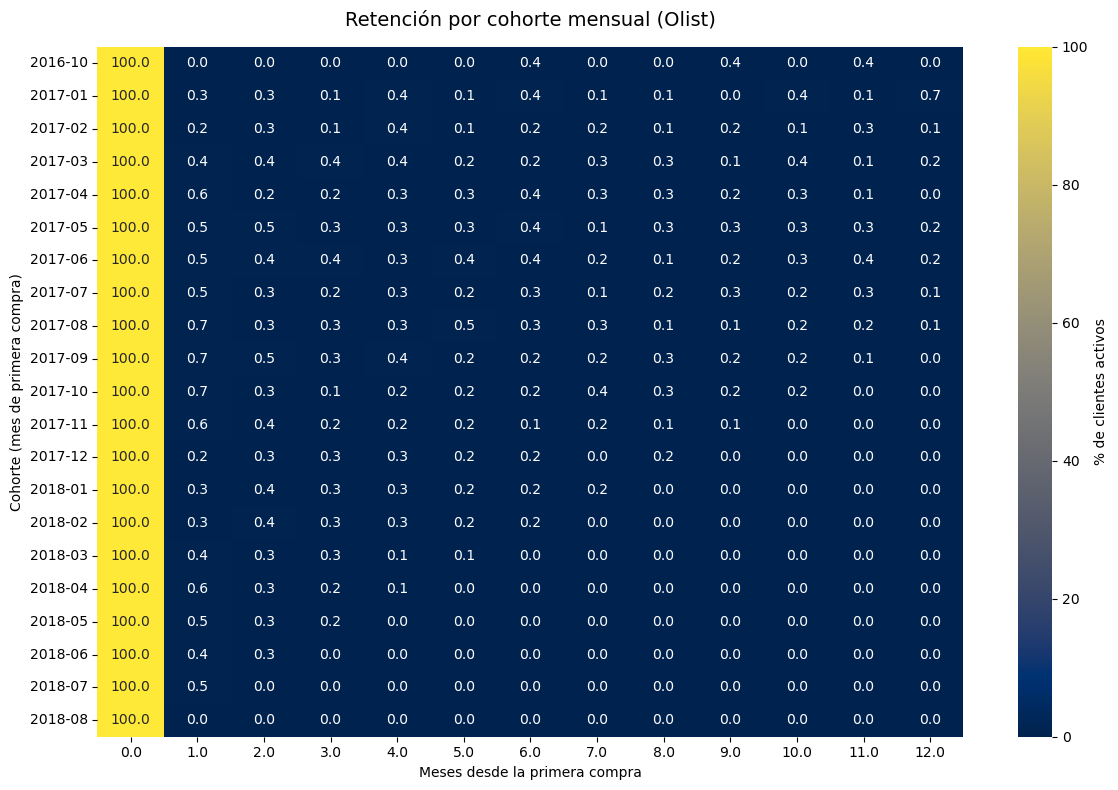

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Formatear las cohortes a "año-mes" legible
matriz_plot = matriz_pct.copy()
matriz_plot.index = matriz_plot.index.strftime('%Y-%m')

# Quedarnos con los primeros 12 meses (columnas 0 a 12)
matriz_plot = matriz_plot.loc[:, 0:12] 
# Año 2018-08 solo ha tenido tiempo de vivir un mes o dos antes de que acabe el dataset (oct-2018) Por eso es 0.0 no es por peor retencion
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_plot, annot=True, fmt='.1f', cmap='cividis', 
            cbar_kws={'label': '% de clientes activos'})
plt.title('Retención por cohorte mensual (Olist)', fontsize=14, pad=15)
plt.xlabel('Meses desde la primera compra')
plt.ylabel('Cohorte (mes de primera compra)')
plt.tight_layout()
path = "C:/Users/Usuario/Documents/Brazilian-dataset-ecommerce-proyecto/"
plt.savefig(path + "matriz_cohortes.png")
plt.show()



In [6]:
consulta_entrega = """
WITH pedidos_numerados AS (
    SELECT 
        c.customer_unique_id,
        o.order_purchase_timestamp,
        o.order_delivered_customer_date,
        ROW_NUMBER() OVER (
            PARTITION BY c.customer_unique_id 
            ORDER BY o.order_purchase_timestamp
        ) AS num_pedido,
        COUNT(*) OVER (PARTITION BY c.customer_unique_id) AS total_pedidos
    FROM customers AS c
    JOIN orders AS o ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
        AND o.order_delivered_customer_date IS NOT NULL
)
SELECT 
    customer_unique_id,
    EXTRACT(DAY FROM (order_delivered_customer_date - order_purchase_timestamp)) AS dias_entrega,
    CASE WHEN total_pedidos >= 2 THEN 'Repitió' ELSE 'No repitió' END AS tipo_cliente
FROM pedidos_numerados
WHERE num_pedido = 1;
"""

df_entrega = pd.read_sql(consulta_entrega, engine)
print(df_entrega.shape)
df_entrega.head(8)

(93350, 3)


,customer_unique_id,dias_entrega,tipo_cliente
0,0000366f3b9a7992bf8c76cfdf3221e2,6.0,No repitió
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3.0,No repitió
2,0000f46a3911fa3c0805444483337064,25.0,No repitió
3,0000f6ccb0745a6a4b88665a16c9f078,20.0,No repitió
4,0004aac84e0df4da2b147fca70cf8255,13.0,No repitió
5,0004bd2a26a76fe21f786e4fbd80607f,1.0,No repitió
6,00050ab1314c0e55a6ca13cf7181fecf,6.0,No repitió
7,00053a61a98854899e70ed204dd4bafe,16.0,No repitió


In [7]:
df_entrega.groupby('tipo_cliente')['dias_entrega'].agg(['count', 'mean', 'median'])

,count,mean,median
tipo_cliente,,,
No repitió,90549,12.109863,10.0
Repitió,2801,11.902178,10.0


In [8]:
consulta_valor = """
WITH pedidos_numerados AS (
    SELECT 
        c.customer_unique_id,
        o.order_id,
        o.order_purchase_timestamp,
        ROW_NUMBER() OVER (
            PARTITION BY c.customer_unique_id 
            ORDER BY o.order_purchase_timestamp
        ) AS num_pedido,
        COUNT(*) OVER (PARTITION BY c.customer_unique_id) AS total_pedidos
    FROM customers AS c
    JOIN orders AS o ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
),
primer_pedido AS (
    SELECT 
        customer_unique_id,
        order_id,
        CASE WHEN total_pedidos >= 2 THEN 'Repitió' ELSE 'No repitió' END AS tipo_cliente
    FROM pedidos_numerados
    WHERE num_pedido = 1
)
SELECT 
    pp.customer_unique_id,
    pp.tipo_cliente,
    SUM(oi.price) AS valor_primer_pedido
FROM primer_pedido AS pp
JOIN order_items AS oi ON pp.order_id = oi.order_id
GROUP BY pp.customer_unique_id, pp.tipo_cliente;
"""

df_valor = pd.read_sql(consulta_valor, engine)
print(df_valor.shape)
df_valor.head()

(93358, 3)


,customer_unique_id,tipo_cliente,valor_primer_pedido
0,0000366f3b9a7992bf8c76cfdf3221e2,No repitió,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,No repitió,18.90
2,0000f46a3911fa3c0805444483337064,No repitió,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,No repitió,25.99
4,0004aac84e0df4da2b147fca70cf8255,No repitió,180.00


In [9]:
df_valor.groupby('tipo_cliente')['valor_primer_pedido'].agg(['count', 'mean', 'median'])

,count,mean,median
tipo_cliente,,,
No repitió,90557,137.958295,86.96
Repitió,2801,122.420503,80.00


In [10]:
consulta_review = """
WITH pedidos_numerados AS (
    SELECT 
        c.customer_unique_id,
        o.order_id,
        o.order_purchase_timestamp,
        ROW_NUMBER() OVER (
            PARTITION BY c.customer_unique_id 
            ORDER BY o.order_purchase_timestamp
        ) AS num_pedido,
        COUNT(*) OVER (PARTITION BY c.customer_unique_id) AS total_pedidos
    FROM customers AS c
    JOIN orders AS o ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
),
primer_pedido AS (
    SELECT 
        customer_unique_id,
        order_id,
        CASE WHEN total_pedidos >= 2 THEN 'Repitió' ELSE 'No repitió' END AS tipo_cliente
    FROM pedidos_numerados
    WHERE num_pedido = 1
)
SELECT 
    pp.customer_unique_id,
    pp.tipo_cliente,
    r.review_score
FROM primer_pedido AS pp
JOIN order_reviews AS r ON pp.order_id = r.order_id;
"""

df_review = pd.read_sql(consulta_review, engine)
print(df_review.shape)
df_review.head()


(93030, 3)


,customer_unique_id,tipo_cliente,review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,No repitió,5
1,0000b849f77a49e4a4ce2b2a4ca5be3f,No repitió,4
2,0000f46a3911fa3c0805444483337064,No repitió,3
3,0000f6ccb0745a6a4b88665a16c9f078,No repitió,4
4,0004aac84e0df4da2b147fca70cf8255,No repitió,5


In [11]:
tabla = df_review.groupby('review_score')['tipo_cliente'].value_counts(normalize=True).unstack() * 100
tabla

tipo_cliente,No repitió,Repitió
review_score,,
1,96.961053,3.038947
2,96.940928,3.059072
3,96.852647,3.147353
4,97.045726,2.954274
5,96.676248,3.323752


In [17]:
consulta_clientes_nuevos_por_año= """
SELECT
    DATE_TRUNC('year', fecha_primera) AS anio,
    COUNT(*) AS clientes_nuevos
FROM (
    SELECT c.customer_unique_id, MIN(o.order_purchase_timestamp) AS fecha_primera
    FROM customers AS c
    JOIN orders AS o ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
) AS primeras
GROUP BY anio
ORDER BY anio;
"""
df_review = pd.read_sql(consulta_clientes_nuevos_por_año, engine)
print(df_review.shape)
df_review.head()

(3, 2)


,anio,clientes_nuevos
0,2016-01-01,264
1,2017-01-01,42131
2,2018-01-01,50963


In [19]:
consulta_valor_tipico_recompra= """
SELECT 
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY valor) AS mediana_valor_recompra
FROM (
    SELECT o.order_id, SUM(oi.price) AS valor
    FROM customers AS c
    JOIN orders AS o ON c.customer_id = o.customer_id
    JOIN order_items AS oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY o.order_id
) AS pedidos;
"""
df_review = pd.read_sql(consulta_valor_tipico_recompra, engine)
print(df_review.shape)
df_review.head()

(1, 1)


,mediana_valor_recompra
0,86.575
